<a href="https://colab.research.google.com/github/kumarpal1107/pythonbasics/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1
Simple Linear Regression is a statistical technique used to model the relationship between two continuous variables — one independent variable (X) and one dependent variable (Y). It assumes a linear relationship of the form:
[ Y = β₀ + β₁X + ε ] where:

( β₀ ) = intercept,
( β₁ ) = slope,
( ε ) = error term. It helps predict the value of Y based on a given value of X.

In [ ]:
#2
Linearity – The relationship between X and Y is linear.
Independence – Observations are independent of each other.
Homoscedasticity – Constant variance of residuals across all levels of X.
Normality – Residuals are normally distributed.
No multicollinearity – (only relevant when multiple predictors are used).

In [ ]:
#3
Heteroscedasticity occurs when the variance of residuals is not constant across all levels of the independent variable(s). It violates the homoscedasticity assumption of regression and leads to:

Inefficient estimates of coefficients.
Inaccurate standard errors, making hypothesis tests unreliable. Addressing it ensures valid statistical inference and model reliability.

In [ ]:
#4
Multiple Linear Regression (MLR) models the relationship between one dependent variable (Y) and two or more independent variables (X₁, X₂, …, Xₙ). The general form is:

[ Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε ]

It helps assess how multiple factors collectively influence a single outcome.

In [ ]:
#5
Polynomial Regression models the relationship between X and Y using higher-degree terms of X (e.g., X², X³) to capture curvature. It differs from simple linear regression, which assumes a straight-line relationship. Example:

[ Y = β₀ + β₁X + β₂X² + ε ]

Polynomial regression can model non-linear relationships between variables.

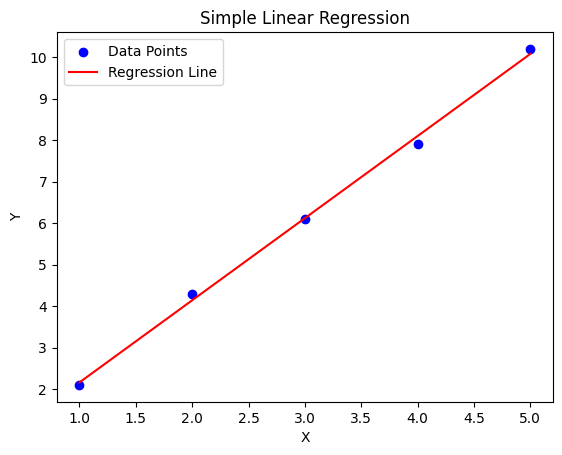

Coefficient: 1.9800000000000004
Intercept: 0.17999999999999794


In [1]:
#6
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Model fitting
model = LinearRegression()
model.fit(X, Y)

# Predictions
Y_pred = model.predict(X)

# Plot
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

In [2]:
#7

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data
data = pd.DataFrame({
    'Area': [1200, 1500, 1800, 2000],
    'Rooms': [2, 3, 3, 4],
    'Price': [250000, 300000, 320000, 370000]
})

X = data[['Area', 'Rooms']]
y = data['Price']

# Add constant for intercept
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print(model.summary())
print("\nVariance Inflation Factor:\n", vif_data)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     351.0
Date:                Sun, 05 Jul 2026   Prob (F-statistic):             0.0377
Time:                        07:56:18   Log-Likelihood:                -35.242
No. Observations:                   4   AIC:                             76.48
Df Residuals:                       1   BIC:                             74.64
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+05   9488.293     10.872      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


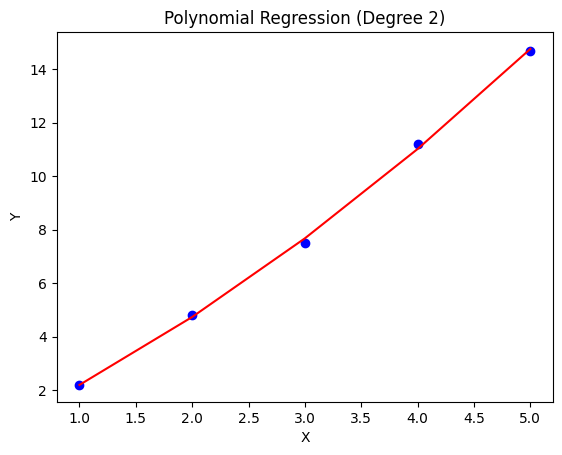

In [3]:
#8
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Transform to polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit model
model = LinearRegression()
model.fit(X_poly, Y)
Y_pred = model.predict(X_poly)

# Plot
plt.scatter(X, Y, color='blue')
plt.plot(X, Y_pred, color='red')
plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

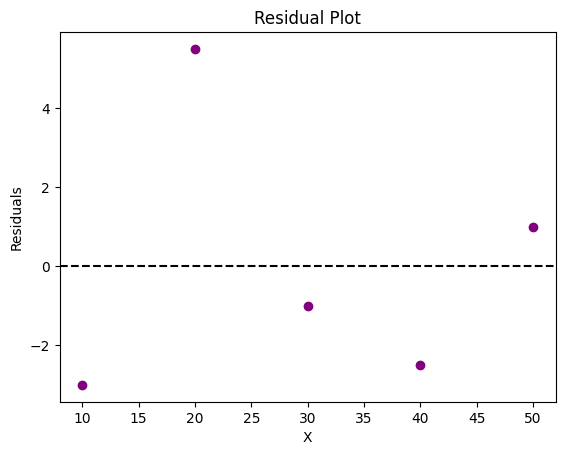

In [4]:
#9
# Data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# Model
model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)
residuals = Y - Y_pred

# Residual plot
plt.scatter(X, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("X")
plt.ylabel("Residuals")
plt.show()

In [ ]:
#10
To ensure a robust regression model:

For Heteroscedasticity:

Use log or Box-Cox transformations on the dependent variable.
Apply Weighted Least Squares (WLS) to handle unequal variance.
Use robust standard errors to adjust variance estimates.
For Multicollinearity:

Examine VIF values and remove or combine highly correlated predictors.
Use Principal Component Analysis (PCA) or Regularization methods like Ridge or Lasso Regression.
Collect more data or transform variables if feasible.